# Loading data

In [1]:
import pandas as pd

reviews = pd.read_json("Video_Games.jsonl", lines=True)
meta = pd.read_json("meta_Video_Games.jsonl", lines=True)

In [2]:
print("\nReviews DataFrame Shape:")
display(reviews.shape)
print("\nMeta DataFrame Shape:")
display(meta.shape)


Reviews DataFrame Shape:


(4624615, 10)


Meta DataFrame Shape:


(137269, 16)

# Rating frequency distribution

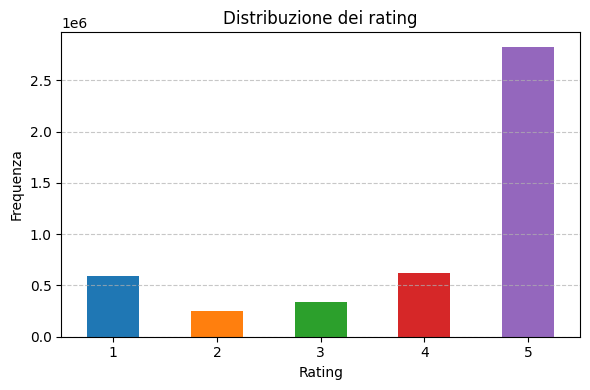

rating
1     589519
2     249878
3     340086
4     617251
5    2827881
Name: count, dtype: int64

In [3]:
import matplotlib.pyplot as plt

counts = reviews['rating'].value_counts().sort_index()

plt.figure(figsize=(6,4))

colors = plt.cm.tab10(range(len(counts)))
counts.plot(kind='bar', color=colors)

plt.xlabel('Rating')
plt.ylabel('Frequenza')
plt.title('Distribuzione dei rating')
plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
display(counts)

# User count by number of reviews

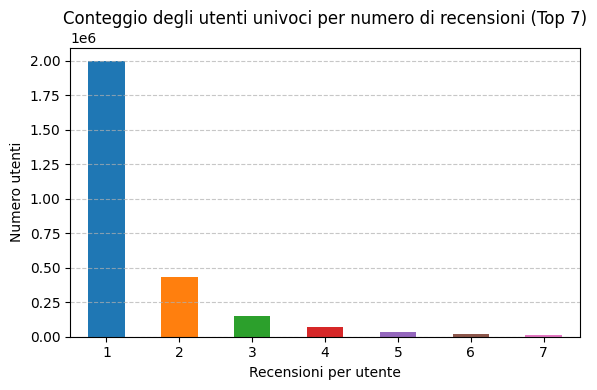

1    1997753
2     429735
3     148841
4      72585
5      36437
6      23247
7      13883
Name: count, dtype: int64

In [4]:
user_review_counts = reviews.groupby("user_id").size()

counts = user_review_counts.value_counts().sort_index()

counts = counts.sort_values(ascending=False).head(7)

plt.figure(figsize=(6,4))

colors = plt.cm.tab10(range(len(counts)))
counts.plot(kind='bar', color=colors)

plt.xlabel('Recensioni per utente')
plt.ylabel('Numero utenti')
plt.title('Conteggio degli utenti univoci per numero di recensioni (Top 7)')
plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
display(counts)

# Item count by number of reviews

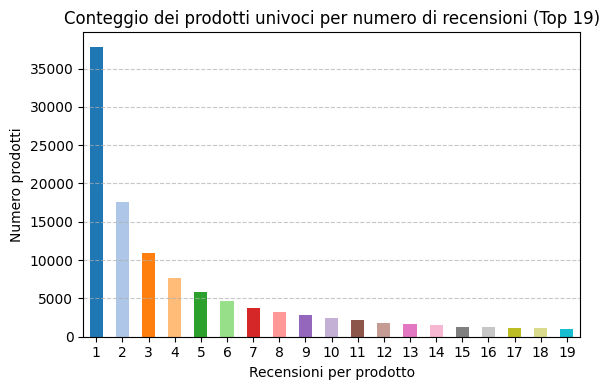

1     37839
2     17636
3     10920
4      7674
5      5852
6      4650
7      3808
8      3211
9      2844
10     2393
11     2237
12     1848
13     1681
14     1467
15     1317
16     1288
17     1151
18     1094
19     1003
Name: count, dtype: int64

In [16]:
item_review_counts = reviews.groupby("parent_asin").size()

counts = item_review_counts.value_counts().sort_index()

counts = counts.sort_values(ascending=False).head(19)

plt.figure(figsize=(6,4))

colors = plt.cm.tab20(range(len(counts)))
counts.plot(kind='bar', color=colors)

plt.xlabel('Recensioni per prodotto')
plt.ylabel('Numero prodotti')
plt.title('Conteggio dei prodotti univoci per numero di recensioni (Top 19)')
plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
display(counts)

In [17]:
reviews["num_images"] = reviews["images"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

In [18]:
print("\nNumber of reviews by image count (top 5):")
display(reviews["num_images"].value_counts().sort_index().head())

print("\nNumber of reviews by helpful votes count (top 5):")
reviews = reviews[reviews["helpful_vote"] >= 0]
display(reviews["helpful_vote"].value_counts().sort_index().head())


Number of reviews by image count (top 5):


num_images
0    4419914
1     115307
2      45483
3      21988
4      10465
Name: count, dtype: int64


Number of reviews by helpful votes count (top 5):


helpful_vote
0    3456888
1     581781
2     200724
3     103322
4      61319
Name: count, dtype: int64

# Correlation: (review length, helpful votes, number of images)

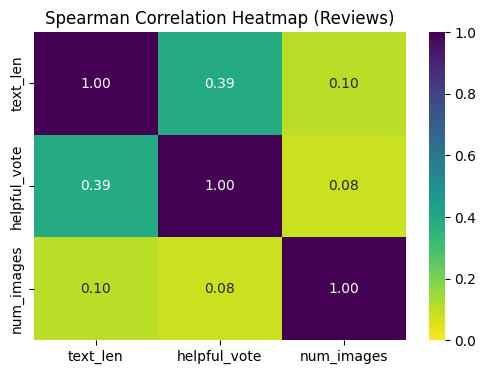

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

reviews["text_len"] = reviews["text"].astype(str).str.len()

cols = ["text_len", "helpful_vote", "num_images"]

temp = reviews[cols].copy().dropna(subset=cols)
corr = temp.corr(method="spearman")

plt.figure(figsize=(6,4))
sns.heatmap(
    corr,
    annot=True,
    cmap="viridis_r",
    vmin=0, vmax=1,
    fmt=".2f"
)

plt.title("Spearman Correlation Heatmap (Reviews)")
plt.show()

# Average helpful votes: reviews with image VS reviews without image

In [20]:
no_images = reviews[reviews["num_images"] == 0]
with_images = reviews[reviews["num_images"] > 0]

mean_no_images = no_images["helpful_vote"].mean()
mean_with_images = with_images["helpful_vote"].mean()

print("Average helpful votes (no images):", mean_no_images)
print("Average helpful votes (with images):", mean_with_images)
print("Average helpful votes (with and without images):", reviews["helpful_vote"].mean())

Average helpful votes (no images): 1.1507194824875513
Average helpful votes (with images): 2.8962779859404693
Average helpful votes (with and without images): 1.2279837841601482


# Correlation: (price, average rating, rating numbers)

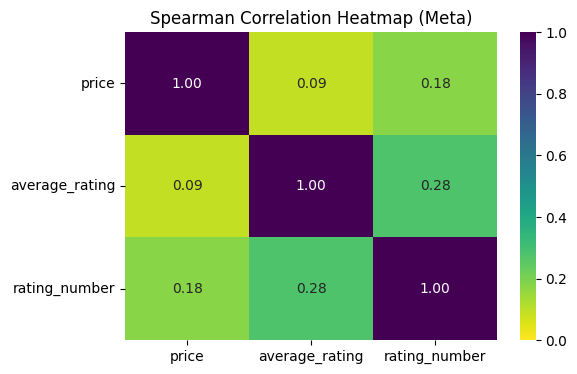

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["price", "average_rating", "rating_number"]

temp = meta[cols].copy().dropna(subset=cols)

temp["price"] = (
    temp["price"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

temp["price"] = pd.to_numeric(temp["price"], errors="coerce")

corr_meta = temp.corr(method="spearman")

plt.figure(figsize=(6,4))
sns.heatmap(
    corr_meta,
    annot=True,
    cmap="viridis_r",
    vmin=0, vmax=1,
    fmt=".2f"
)

plt.title("Spearman Correlation Heatmap (Meta)")
plt.show()

# Keeping only relevant columns then check for NaNs

In [22]:
import numpy as np

reviews = reviews[["rating", "parent_asin", "user_id"]].copy()
meta = meta[["title", "description", "parent_asin"]].copy()

reviews = reviews.replace(r'^\s*$', np.nan, regex=True)
meta = meta.replace(r'^\s*$', np.nan, regex=True)

print("\nReviews NaN count:")
print(reviews[["rating", "parent_asin", "user_id"]].isna().sum())

print("\nMeta NaN count:")
print(meta[["title", "description", "parent_asin"]].isna().sum())

print("\nShapes:")
print("reviews_clean:", reviews.shape)
print("meta_clean:", meta.shape)



Reviews NaN count:
rating         0
parent_asin    0
user_id        0
dtype: int64

Meta NaN count:
title          9
description    0
parent_asin    0
dtype: int64

Shapes:
reviews_clean: (4624614, 3)
meta_clean: (137269, 3)


# Removing rows with missing values then remove rows associated with the removed rows

In [23]:
meta_clean = meta.dropna(subset=["title"]).copy()

valid_parent_asin = set(meta_clean["parent_asin"])

reviews_clean = reviews[
    reviews["parent_asin"].isin(valid_parent_asin)
].copy()

print("\nMETA NaN count:")
print(meta_clean[["title", "description", "parent_asin"]].isna().sum())

print("\nREVIEWS NaN count:")
print(reviews_clean[["rating", "parent_asin", "user_id"]].isna().sum())

print("\nShapes:")
print("reviews_clean:", reviews_clean.shape)
print("meta_clean:", meta_clean.shape)


META NaN count:
title          0
description    0
parent_asin    0
dtype: int64

REVIEWS NaN count:
rating         0
parent_asin    0
user_id        0
dtype: int64

Shapes:
reviews_clean: (4624175, 3)
meta_clean: (137260, 3)


# More statistics

In [24]:
display(
    reviews_clean
        .groupby('user_id')
        .size()
        .describe()
        .rename({
            'count': 'Numero utenti univoci',
            'mean': 'Recensioni medie per utente',
            'std': 'Deviazione standard',
            'min': 'Min recensioni utente',
            '25%': '25% utenti ≤',
            '50%': 'Mediana (50%)',
            '75%': '75% utenti ≤',
            'max': 'Max recensioni utente'
        })
        .apply(lambda x: f"{x:.2f}")
)

display(
    reviews_clean
        .groupby('parent_asin')
        .size()
        .describe()
        .rename({
            'count': 'Numero prodotti',
            'mean': 'Recensioni medie per prodotto',
            'std': 'Deviazione standard',
            'min': 'Min recensioni prodotto',
            '25%': '25% prodotti ≤',
            '50%': 'Mediana (50%)',
            '75%': '75% prodotti ≤',
            'max': 'Max recensioni prodotto'
        })
        .apply(lambda x: f"{x:.2f}")
)

display(
    reviews_clean['rating']
        .describe()
        .rename({
            'count': 'Numero rating',
            'mean': 'Rating medio',
            'std': 'Deviazione standard',
            'min': 'Rating minimo',
            '25%': '25% rating ≤',
            '50%': 'Mediana (50%)',
            '75%': '75% rating ≤',
            'max': 'Rating massimo'
        })
        .apply(lambda x: f"{x:.4f}")
)

Numero utenti univoci          2766433.00
Recensioni medie per utente          1.67
Deviazione standard                  2.42
Min recensioni utente                1.00
25% utenti ≤                         1.00
Mediana (50%)                        1.00
75% utenti ≤                         2.00
Max recensioni utente              664.00
dtype: str

Numero prodotti                  137240.00
Recensioni medie per prodotto        33.69
Deviazione standard                 200.26
Min recensioni prodotto               1.00
25% prodotti ≤                        1.00
Mediana (50%)                         4.00
75% prodotti ≤                       14.00
Max recensioni prodotto           18105.00
dtype: str

Numero rating          4624175.0000
Rating medio                 4.0475
Deviazione standard          1.4304
Rating minimo                1.0000
25% rating ≤                 3.0000
Mediana (50%)                5.0000
75% rating ≤                 5.0000
Rating massimo               5.0000
Name: rating, dtype: str

# Checking sparsity

$$
\Large
\text{sparsity} = 1 - \frac{\text{rating osservati}}{\text{utenti} \times \text{item}}
$$

In [25]:
n_users = reviews_clean['user_id'].nunique()
n_items = reviews_clean['parent_asin'].nunique()
n_ratings = len(reviews_clean)

sparsity = 1 - (n_ratings / (n_users * n_items))

print(f"{sparsity*100:.6f}% delle celle sono vuote")

99.998782% delle celle sono vuote


# Saving cleaned data in csv format to use later

In [ ]:
reviews_clean.to_csv("reviews_clean.csv", index=False)
meta_clean.to_csv("meta_clean.csv", index=False)